### step 1: importing the data
- Create a simple code snippet to automaticly download the data as a csv


In [1]:
import mlcroissant as mlc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Datalist = mlc.Dataset add link to data set


df = pd.read_csv("draft_phase.csv")


### Step 2: check the dataset

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2988 entries, 0 to 2987
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Tournament  2988 non-null   str  
 1   Stage       2988 non-null   str  
 2   Match Type  2988 non-null   str  
 3   Match Name  2988 non-null   str  
 4   Team        2988 non-null   str  
 5   Action      2988 non-null   str  
 6   Map         2988 non-null   str  
dtypes: str(7)
memory usage: 163.5 KB


Describe each column of data!!!

### step 3: culling unnesacary data

for my business problem there are multiple columns which either provide no impact to the indepedant variable, or complicate the matter with very little effect on the indepedant variable.

thus we should cull them to get a much simpler and easier to design solution


### the unnecassary data points are:

tournament type: 
- this is unnecassary as it does not impact what maps are chosen, only where the teams play

stage: 
- again only impacts where in the world the teams play

match type:
- only usefull to know what brackets the teams are in, and only impacts who vs's who



In [3]:
df = df.drop(columns=["Tournament", "Stage", "Match Type"])


We are then left with 4 columns:

Match name:
- this will be split along the "vs" to find what teams pick which maps against other teams

now we can find out how many unique teams there are


In [4]:
teams = sorted(df["Team"].dropna().unique())
print(f"unique teams: {len(teams)}")
print(teams)

unique teams: 48
['100 Thieves', '2Game Esports', 'All Gamers', 'Apeks', 'BBL Esports', 'BOOM Esports', 'Bilibili Gaming', 'Cloud9', 'DRX', 'DetonatioN FocusMe', 'Dragon Ranger Gaming', 'EDward Gaming', 'Evil Geniuses', 'FNATIC', 'FURIA', 'FUT Esports', 'FunPlus Phoenix', 'G2 Esports', 'GIANTX', 'Gen.G', 'Gentle Mates', 'Global Esports', 'JDG Esports', 'KOI', 'KRÜ Esports', 'Karmine Corp', 'LEVIATÁN', 'LOUD', 'MIBR', 'Mega Minors', 'Natus Vincere', 'Nongshim RedForce', 'Nova Esports', 'Paper Rex', 'Rex Regum Qeon', 'Sentinels', 'T1', 'TALON', 'TYLOO', 'Team Heretics', 'Team Liquid', 'Team Secret', 'Team Vitality', 'Titan Esports Club', 'Trace Esports', 'Wolves Esports', 'Xi Lai Gaming', 'ZETA DIVISION']


and now we can find how many unique maps there are

Sorts through maps dosent pick up NA values and finds all unique values

In [5]:
maps = sorted(df["Map"].dropna().unique())
print(f"unique maps: {len(maps)}")
print(maps)

unique maps: 11
['Abyss', 'Ascent', 'Bind', 'Corrode', 'Fracture', 'Haven', 'Icebox', 'Lotus', 'Pearl', 'Split', 'Sunset']


Now we know that there are 48 teams with 11 different picks

So lets now see how many times these teams amd maps appear

In [6]:
team_amount = df["Team"].value_counts()
map_amount = df["Map"].value_counts()
print(team_amount)
print(map_amount)

Team
G2 Esports              116
Team Liquid             102
Paper Rex               101
FNATIC                  101
DRX                      94
T1                       94
Sentinels                93
EDward Gaming            92
Rex Regum Qeon           85
MIBR                     84
Xi Lai Gaming            82
Bilibili Gaming          82
Team Heretics            80
Gen.G                    76
Mega Minors              75
Dragon Ranger Gaming     73
GIANTX                   71
Wolves Esports           69
BBL Esports              66
TALON                    63
Team Vitality            61
Trace Esports            58
Cloud9                   57
100 Thieves              57
Natus Vincere            57
Nongshim RedForce        57
KRÜ Esports              54
Evil Geniuses            51
FUT Esports              51
LEVIATÁN                 48
Nova Esports             48
Karmine Corp             45
DetonatioN FocusMe       45
Titan Esports Club       45
TYLOO                    45
All Gamers     

now lets see how many times each map is banned and picked

In [9]:
ban_counts = df.loc[df["Action"].eq("ban"), "Map"].value_counts()
print(f"banned {ban_counts}")

pick_counts = df.loc[df["Action"].eq("pick"), "Map"].value_counts()
print(f"picked {pick_counts}")

banned Map
Haven       262
Lotus       229
Ascent      229
Icebox      224
Pearl       179
Bind        169
Fracture    169
Split       159
Sunset      128
Corrode     114
Abyss        70
Name: count, dtype: int64
picked Map
Lotus       198
Haven       151
Icebox      103
Ascent       95
Bind         91
Split        82
Pearl        75
Fracture     71
Sunset       70
Corrode      64
Abyss        56
Name: count, dtype: int64


lets see this in a graph


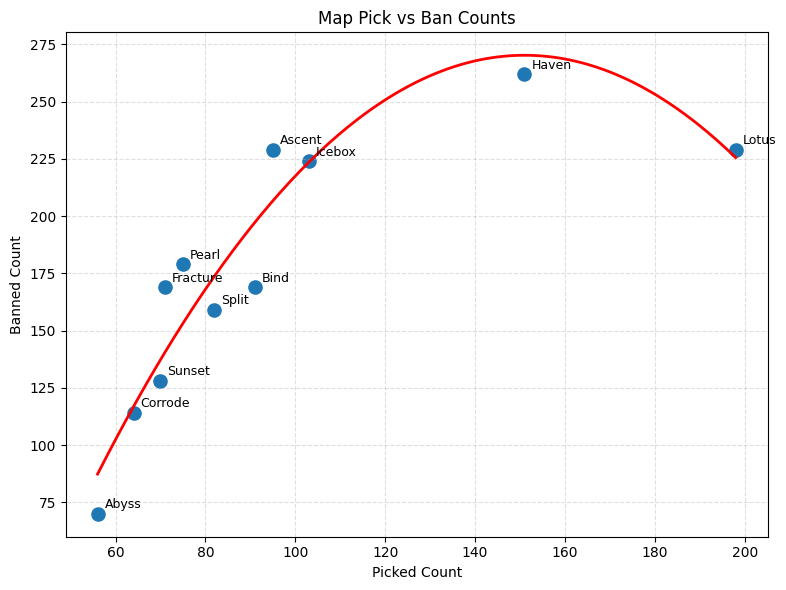

In [12]:
map_action_counts = (
    pd.crosstab(df["Map"], df["Action"])
    .reindex(columns=["ban", "pick"], fill_value=0)
    .sort_index()
)

x = map_action_counts["pick"].to_numpy()
y = map_action_counts["ban"].to_numpy()

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=90, label="Maps")

#line of best fit
degree = 2
coeffs = np.polyfit(x, y, degree)
poly_fn = np.poly1d(coeffs)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = poly_fn(x_fit)
plt.plot(x_fit, y_fit, color="red", linewidth=2, label=f"Best fit (deg {degree})")

# label each dot with map name
for map_name, row in map_action_counts.iterrows():
    plt.annotate(
        map_name,
        (row["pick"], row["ban"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9,
    )

plt.xlabel("Picked Count")
plt.ylabel("Banned Count")
plt.title("Map Pick vs Ban Counts")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

the graph pretty clearly shows a relationship where the more popular a map is to pick to more popular it is to ban, up to a point where the pick rate out weighs the want to ban the map

time to create new data, now that we have an overview of what our data looks like for everyteam, its time to look at what the individual pick/ban rates are for each team